# Blind 번아웃 게시글 분석

> **파이프라인**  
> `blind_raw.csv 로드` → `전처리` → **분석 단위 선택** → `형태소 분석(Kiwi)`  
> → **방법 1** TF-IDF + KMeans  
> → **방법 2** Doc2Vec + KMeans  
> → **방법 3** SBERT + KMeans  
> → 군집별 키워드 & 대표문장 해석 → 결과 저장

---
### 📌 분석 단위 2가지 모드
| 모드 | `ANALYSIS_MODE` | 분석 단위 | 특징 |
|------|----------------|-----------|------|
| 문장 분리 | `"sentence"` | 게시글을 문장 단위로 쪼개서 분석 | 세밀한 토픽 발견에 유리 |
| 문서 전체 | `"document"` | 게시글 본문(clean_body) 통째로 분석 | 게시글 전체 맥락 보존에 유리 |

> **STEP 2의 `ANALYSIS_MODE` 변수 하나만 바꾸면** 이후 모든 셀이 자동으로 대응합니다.

## STEP 0. 패키지 설치

In [1]:
# 처음 실행 시 주석 해제
!pip install kiwipiepy umap-learn scikit-learn gensim matplotlib pandas tqdm
!pip install sentence-transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 MB 10.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 9.7 MB/s eta 0:00:00
  Created wheel for kiwipiepy_model: filename=kiwipiepy_model-0.22.1-py3-none-any.whl size=79578111 sha256=5ca3e95859976daa99b033d6dce0bedf49ea43170ca073beae68e4be8dd11d51
  Stored in directory: /root/.cache/pip/wheels/c0/5a/4b/a1abeb73f3d31c5d010d4163bc08686d5539766084ecba0e1a
Successfully built kiwipiepy_model


## STEP 1. 데이터 로드 & 전처리

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import re
from tqdm import tqdm

RAW_CSV = "/content/drive/MyDrive/Colab Notebooks/LG전자DX스쿨/CX Project/data/03_Apartment_Options_merged.csv"   # 크롤링 결과 파일명 (필요 시 수정)


raw_df = pd.read_csv((RAW_CSV), encoding="utf-8-sig")
raw_df = raw_df.dropna(subset=["text"]).reset_index(drop=True)
print(f"게시글 수: {len(raw_df)}건")
raw_df.head(3)

게시글 수: 57404건


,url,date,title,content,text,source_file
0,https://cafe.naver.com/overseer/1583750?art=ZX...,2026.03.04. 15:29,"자유수다방신축아파트 옵션은,,?(도와주세여..)","곧 신축 아파트 옵션을 골라야하는데.. 시스템 에어컨, 바닥 이렇게 할 생각입니다....","자유수다방신축아파트 옵션은,,?(도와주세여..) 곧 신축 아파트 옵션을 골라야하는데...",네이버카페_아파트_옵션_crawling
1,https://cafe.naver.com/mapleless/169826?art=ZX...,2026.02.24. 15:53,자유게시판아파트 옵션 확인할 수 있는 곳 있나요?,주변에 지어진지 5-6년 정도 된 아파트 단지가 있어서 고객님들에게 설명할 수 있는...,자유게시판아파트 옵션 확인할 수 있는 곳 있나요? 주변에 지어진지 5-6년 정도 된...,네이버카페_아파트_옵션_crawling
2,https://cafe.naver.com/landshop/626087?art=ZXh...,2026.03.08. 00:19,자유게시판아파트 에어컨 옵션관련,안녕하세요 미혼이구 결혼은 아직 예정없습니다 아파트 실거주목적 입주로 옵션선택을 해...,자유게시판아파트 에어컨 옵션관련 안녕하세요 미혼이구 결혼은 아직 예정없습니다 아파트...,네이버카페_아파트_옵션_crawling


In [4]:
def clean_text(text):
    """URL 제거, 특수문자 제거, 공백 정규화"""
    text = re.sub(r"https?://\S+", "", text)
    text = re.sub(r"[^a-zA-Z0-9가-힣\s\n.,!?]", "", text)
    text = re.sub(r"[ \t]+", " ", text)
    return text.strip()

raw_df["clean_body"] = raw_df["text"].apply(clean_text)
print("전처리 완료 ✅")
raw_df[[ "clean_body"]].head(3)

전처리 완료 ✅


,clean_body
0,"자유수다방신축아파트 옵션은,,?도와주세여.. 곧 신축 아파트 옵션을 골라야하는데....."
1,자유게시판아파트 옵션 확인할 수 있는 곳 있나요? 주변에 지어진지 56년 정도 된 ...
2,자유게시판아파트 에어컨 옵션관련 안녕하세요 미혼이구 결혼은 아직 예정없습니다 아파트...


## STEP 2. 분석 단위 선택 ⬅️ 여기서 모드를 선택하세요

```
ANALYSIS_MODE = "sentence"   # 문장 분리 모드
ANALYSIS_MODE = "document"   # 문서 전체 모드
```

In [5]:
# ─── 모드 선택 ───────────────────────────────────────────────
ANALYSIS_MODE = "document"   # "sentence" | "document"
# ─────────────────────────────────────────────────────────────

def is_noise(s):
    s = s.strip()
    if re.search(r'https?://', s): return True
    if re.fullmatch(r'[\u2500\-\s]+', s): return True
    BOILERPLATE = ["MBTI 검사", "이 서비스는", "신고하기", "공유하기"]
    return any(p in s for p in BOILERPLATE)

def split_sentences(text):
    """\\n 및 .!? 기준 문장 분리, 10자 미만 제거"""
    lines = text.split("\n")
    sentences = []
    for line in lines:
        parts = re.split(r'(?<=[.!?])\s+', line.strip())
        sentences.extend(parts)
    return [s.strip() for s in sentences if len(s.strip()) >= 10]


if ANALYSIS_MODE == "sentence":
    # ── 문장 분리 모드 ──────────────────────────────────────────
    records = []
    for doc_idx, row in raw_df.iterrows():
        for sent in split_sentences(str(row["clean_body"])):
            if not is_noise(sent):
                records.append({
                    "doc_idx" : doc_idx,
                    "url"     : row["url"],
                    "title"   : row["제목"],
                    "text"    : sent       # 공통 컬럼명: text
                })
    analysis_df = pd.DataFrame(records).reset_index(drop=True)
    TEXT_COL = "text"
    print(f"[sentence 모드] 게시글 {len(raw_df)}건 → 문장 {len(analysis_df)}개 ✅")

else:
    # ── 문서 전체 모드 ─────────────────────────────────────────
    analysis_df = raw_df[[ "clean_body"]].copy()
    analysis_df = analysis_df.rename(columns={"clean_body": "text"})
    analysis_df.insert(0, "doc_idx", analysis_df.index)
    analysis_df = analysis_df[~analysis_df["text"].apply(is_noise)].reset_index(drop=True)
    TEXT_COL = "text"
    print(f"[document 모드] 게시글 {len(analysis_df)}건 ✅")

print(f"\n분석 단위: {'문장' if ANALYSIS_MODE == 'sentence' else '게시글 전체'}")
analysis_df.head()

[document 모드] 게시글 57387건 ✅

분석 단위: 게시글 전체


,doc_idx,text
0,0,"자유수다방신축아파트 옵션은,,?도와주세여.. 곧 신축 아파트 옵션을 골라야하는데....."
1,1,자유게시판아파트 옵션 확인할 수 있는 곳 있나요? 주변에 지어진지 56년 정도 된 ...
2,2,자유게시판아파트 에어컨 옵션관련 안녕하세요 미혼이구 결혼은 아직 예정없습니다 아파트...
3,3,자유게시판아파트 옵션 중도대출 받을때 옵션을 선택한다고 하는데 입주시에 입주자들과 ...
4,4,고민상담신축아파트 조명 옵션 안녕하세요 청약 당첨돼서 내일 옵션계약하러갑니다 근데 ...


In [7]:
import pandas as pd

STOPWORDS_CSV = "/content/drive/MyDrive/Colab Notebooks/LG전자DX스쿨/CX Project/data/ko-stopwords.csv"   # 파일 경로 필요 시 수정

sw_df = pd.read_csv(STOPWORDS_CSV, encoding="utf-8-sig")
base_stopwords = set(sw_df["stopwords"].dropna().str.strip().tolist())

print(f"기본 불용어 수: {len(base_stopwords)}개")
print(f"샘플: {list(base_stopwords)[:15]}")

기본 불용어 수: 599개
샘플: ['설사', '여덟', '하면 할수록', '이 정도의', '어느것', '할 따름이다', '시간', '다만', '불구하고', '륙', '아무거나', '몇', '응당', '에', '한켠으로는']


In [8]:
# ── 군집 키워드 결과에서 확인된 무의미 단어 ───────────────────
CUSTOM_STOPWORDS = {
    "아파트", "옵션","너무", "그냥", "진짜", "정말", "약간", "되게", "꽤", "제일", "가장", "더","더욱", "잘", "못", "안", "다","내가", "나는", "나도", 
    "제가", "저는", "저도", "이게", "그게", "저게", "이거", "그거", "저거","이런", "그런", "저런", "이렇게", "그렇게","여기", "거기", "저기",
    "하고", "하는", "하면", "하기", "해서", "했는데","있는", "있고", "없는", "없고","같고", "같은", "같이","아무것도", "한번", "이번", "그때", "대한", "대하"
}

# ── 합치기 ────────────────────────────────────────────────────
ALL_STOPWORDS = base_stopwords | CUSTOM_STOPWORDS

print(f"기본 불용어  : {len(base_stopwords)}개")
print(f"커스텀 추가  : {len(CUSTOM_STOPWORDS)}개")
print(f"최종 불용어  : {len(ALL_STOPWORDS)}개")

기본 불용어  : 599개
커스텀 추가  : 56개
최종 불용어  : 648개


In [9]:
from kiwipiepy import Kiwi
from tqdm import tqdm

kiwi = Kiwi()

def tokenize(text: str) -> list:
    """
    Kiwi 형태소 분석 + 불용어 제거
    - 추출 품사: NNG(일반명사), NNP(고유명사), VV(동사), VA(형용사)
    - 2글자 이상, ALL_STOPWORDS 제외
    """
    return [
        token.form
        for token in kiwi.tokenize(text)
        if token.tag in ("NNG", "NNP", "VV", "VA")
        and len(token.form) > 1
        and token.form not in ALL_STOPWORDS
    ]

# ── 적용 ─────────────────────────────────────────────────────
tqdm.pandas(desc="형태소 분석 + 불용어 제거")
analysis_df["tokens"]     = analysis_df[TEXT_COL].progress_apply(tokenize)
analysis_df["tokens_str"] = analysis_df["tokens"].apply(lambda x: " ".join(x))

# 토큰 없는 행 제거
before = len(analysis_df)
analysis_df = analysis_df[analysis_df["tokens"].map(len) > 0].reset_index(drop=True)
print(f"완료: {before}건 → {len(analysis_df)}건 (토큰 없는 행 {before - len(analysis_df)}건 제거) ✅")
analysis_df[["text", "tokens"]].head()

형태소 분석 + 불용어 제거: 100%|██████████| 57387/57387 [08:22<00:00, 114.10it/s] 


완료: 57387건 → 57358건 (토큰 없는 행 29건 제거) ✅


,text,tokens
0,"자유수다방신축아파트 옵션은,,?도와주세여.. 곧 신축 아파트 옵션을 골라야하는데.....","[자유, 다방, 신축, 신축, 고르, 시스템, 에어컨, 바닥, 생각, 고민, 조명,..."
1,자유게시판아파트 옵션 확인할 수 있는 곳 있나요? 주변에 지어진지 56년 정도 된 ...,"[자유, 게시판, 확인, 주변, 정도, 고객, 설명, 자료, 만들, 다양, 파악, ..."
2,자유게시판아파트 에어컨 옵션관련 안녕하세요 미혼이구 결혼은 아직 예정없습니다 아파트...,"[자유, 게시판, 에어컨, 관련, 안녕, 미혼, 결혼, 예정, 거주, 목적, 입주,..."
3,자유게시판아파트 옵션 중도대출 받을때 옵션을 선택한다고 하는데 입주시에 입주자들과 ...,"[자유, 게시판, 중도, 대출, 선택, 입주, 입주자, 에어, 오븐]"
4,고민상담신축아파트 조명 옵션 안녕하세요 청약 당첨돼서 내일 옵션계약하러갑니다 근데 ...,"[고민, 상담, 신축, 조명, 안녕, 청약, 당첨, 내일, 옵션계약, 조명, 모르,..."


In [10]:
from collections import Counter

all_tokens = [t for tokens in analysis_df["tokens"] for t in tokens]
top30 = Counter(all_tokens).most_common(30)

print("불용어 제거 후 상위 30개 토큰:")
print("-" * 40)
for word, cnt in top30:
    print(f"  {word:12s}  {cnt:5d}회")

불용어 제거 후 상위 30개 토큰:
----------------------------------------
  신축            46331회
  입주            45917회
  가능            36019회
  빌라            34716회
  선택            21478회
  청소            21102회
  분양            19032회
  에어컨           17910회
  가격            17772회
  정보            16767회
  계약            15890회
  매매            15761회
  월세            15077회
  생각            14732회
  드리            14501회
  시스템           14034회
  전세            13833회
  설치            13782회
  고민            13667회
  공간            13564회
  사용            13331회
  매물            13229회
  마이너스          12867회
  주방            12729회
  자유            12713회
  원룸            12658회
  인테리어          12508회
  차량            12051회
  추가            11854회
  게시판           11782회


## STEP 3. 형태소 분석 (Kiwi)

In [11]:
from kiwipiepy import Kiwi

kiwi = Kiwi()

def tokenize(text: str) -> list:
    """Kiwi — 일반명사(NNG), 고유명사(NNP), 동사(VV), 형용사(VA), 2글자 이상"""
    return [
        token.form
        for token in kiwi.tokenize(text)
        if token.tag in ("NNG", "NNP", "VV", "VA") and len(token.form) > 1
    ]

tqdm.pandas(desc=f"형태소 분석 [{ANALYSIS_MODE} 모드]")
analysis_df["tokens"]     = analysis_df[TEXT_COL].progress_apply(tokenize)
analysis_df["tokens_str"] = analysis_df["tokens"].apply(lambda x: " ".join(x))

# 토큰 없는 행 제거
analysis_df = analysis_df[analysis_df["tokens"].map(len) > 0].reset_index(drop=True)
print(f"형태소 분석 완료: {len(analysis_df)}건 ✅")
analysis_df[[TEXT_COL, "tokens"]].head()

형태소 분석 [document 모드]: 100%|██████████| 57358/57358 [08:29<00:00, 112.61it/s] 


형태소 분석 완료: 57358건 ✅


,text,tokens
0,"자유수다방신축아파트 옵션은,,?도와주세여.. 곧 신축 아파트 옵션을 골라야하는데.....","[자유, 다방, 신축, 아파트, 옵션, 신축, 아파트, 옵션, 고르, 시스템, 에어..."
1,자유게시판아파트 옵션 확인할 수 있는 곳 있나요? 주변에 지어진지 56년 정도 된 ...,"[자유, 게시판, 아파트, 옵션, 확인, 주변, 정도, 아파트, 단지, 고객, 설명..."
2,자유게시판아파트 에어컨 옵션관련 안녕하세요 미혼이구 결혼은 아직 예정없습니다 아파트...,"[자유, 게시판, 아파트, 에어컨, 옵션, 관련, 안녕, 미혼, 결혼, 예정, 아파..."
3,자유게시판아파트 옵션 중도대출 받을때 옵션을 선택한다고 하는데 입주시에 입주자들과 ...,"[자유, 게시판, 아파트, 옵션, 중도, 대출, 옵션, 선택, 입주, 입주자, 에어..."
4,고민상담신축아파트 조명 옵션 안녕하세요 청약 당첨돼서 내일 옵션계약하러갑니다 근데 ...,"[고민, 상담, 신축, 아파트, 조명, 옵션, 안녕, 청약, 당첨, 내일, 옵션계약..."


In [ ]:
from kiwipiepy import Kiwi
kiwi = Kiwi()

# ── 형태소 분석 및 토큰화 함수 ────────────────────────────
def tokenize(text: str) -> list:
    """핵심 품사(명사, 동사, 형용사) 및 2글자 이상 추출"""
    return [
        token.form for token in kiwi.tokenize(text)
        # NNG(일반명사), NNP(고유명사), VV(동사), VA(형용사) 품사 태깅
        if token.tag in ("NNG", "NNP", "VV", "VA") and len(token.form) > 1
    ]

# ── 데이터프레임 적용 및 정제 ──────────────────────────────
# 1. 형태소 분석 적용 (토큰화)
analysis_df["tokens"] = analysis_df["text"].apply(tokenize)

# 2. 분석 결과 시각화를 위한 문자열 변환
analysis_df["tokens_str"] = analysis_df["tokens"].apply(lambda x: " ".join(x))

# 3. 토큰이 없는 무의미한 행 제거
analysis_df = analysis_df[analysis_df["tokens"].map(len) > 0].reset_index(drop=True)

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import TruncatedSVD
import umap
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rc("font", family="Malgun Gothic")   # Mac: AppleGothic
plt.rcParams["axes.unicode_minus"] = False

---
## 방법 3. SBERT + KMeans 군집화

> `jhgan/ko-sroberta-multitask` — 한국어 특화 SBERT 모델.  
> 형태소 분석 없이 원문을 768차원 벡터로 변환하므로 감성·문맥 정보가 가장 잘 보존됩니다.  
> **document 모드**일 때는 긴 텍스트를 512 토큰으로 잘라 임베딩하니 참고하세요.

### 3-1. SBERT 임베딩

In [13]:
from sentence_transformers import SentenceTransformer

sbert = SentenceTransformer("jhgan/ko-sroberta-multitask")
texts = analysis_df[TEXT_COL].tolist()

embeddings = sbert.encode(
    texts,
    batch_size = 32 if ANALYSIS_MODE == "document" else 64,
    show_progress_bar  = True,
    normalize_embeddings = True
)
print(f"임베딩 shape: {embeddings.shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1793 [00:00<?, ?it/s]

임베딩 shape: (57358, 768)


In [ ]:
from sentence_transformers import SentenceTransformer

# 1. 한국어 성능이 검증된 SBERT 모델(ko-sroberta) 로드
sbert = SentenceTransformer("jhgan/ko-sroberta-multitask")

# 2. 전처리된 텍스트 데이터 리스트화
texts = analysis_df["text"].tolist()

# 3. 고차원 벡터 임베딩 생성 (고성능 병렬 처리)
embeddings = sbert.encode(
    texts,
    batch_size=64,           # 대량 데이터 처리를 위한 배치 최적화
    normalize_embeddings=True # 코사인 유사도 계산을 위한 정규화 적용
)

print(f"임베딩 완료: {embeddings.shape}") # (데이터 개수, 768차원)

### 3-2. UMAP 10D 축소 후 최적 K 탐색

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
SBERT K 탐색: 100%|██████████| 12/12 [10:38<00:00, 53.23s/it]


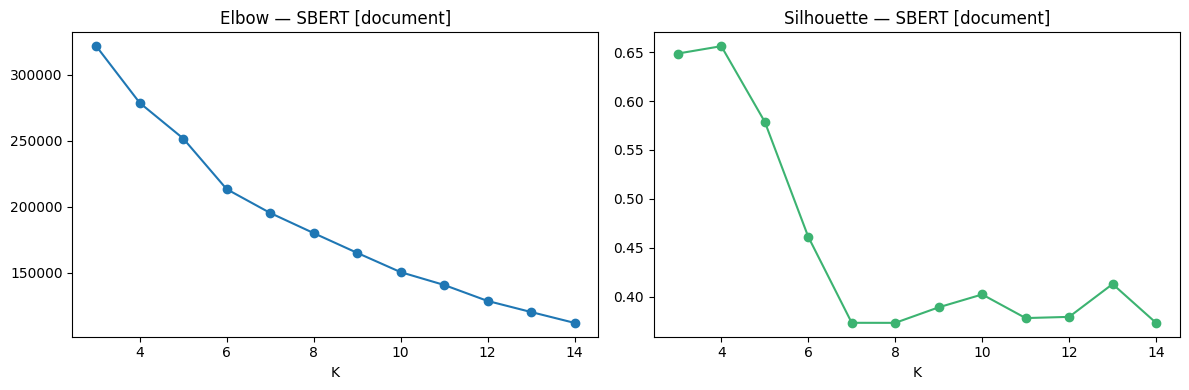

Silhouette 기준 최적 K = 4


In [14]:
reducer_10d = umap.UMAP(n_components=10, metric="cosine", random_state=42)
reduced_10d = reducer_10d.fit_transform(embeddings)

K_RANGE = range(3, 15)
inertias_s, silhouettes_s = [], []

for k in tqdm(K_RANGE, desc="SBERT K 탐색"):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(reduced_10d)
    inertias_s.append(km.inertia_)
    silhouettes_s.append(silhouette_score(reduced_10d, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_RANGE), inertias_s, marker="o")
axes[0].set_title(f"Elbow — SBERT [{ANALYSIS_MODE}]"); axes[0].set_xlabel("K")
axes[1].plot(list(K_RANGE), silhouettes_s, marker="o", color="mediumseagreen")
axes[1].set_title(f"Silhouette — SBERT [{ANALYSIS_MODE}]"); axes[1].set_xlabel("K")
plt.tight_layout(); plt.savefig(f"sbert_optimal_k_{ANALYSIS_MODE}.png", dpi=150); plt.show()

best_k_sbert = list(K_RANGE)[silhouettes_s.index(max(silhouettes_s))]
print(f"Silhouette 기준 최적 K = {best_k_sbert}")

### 3-3. KMeans 군집화 & UMAP 2D 시각화

군집별 게시글 수 (SBERT):
cluster_sbert
0    19445
1    18118
2    19618
3      177
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/tmp/ipykernel_2688/2384680763.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_s = plt.cm.get_cmap("tab10", N_SBERT)
/tmp/ipykernel_2688/2384680763.py:19: UserWarning: Glyph 48264 (\N{HANGUL SYLLABLE BEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(f"sbert_cluster_2d_{ANALYSIS_MODE}.png", dpi=150); plt.show()
/tmp/ipykernel_2688/2384680

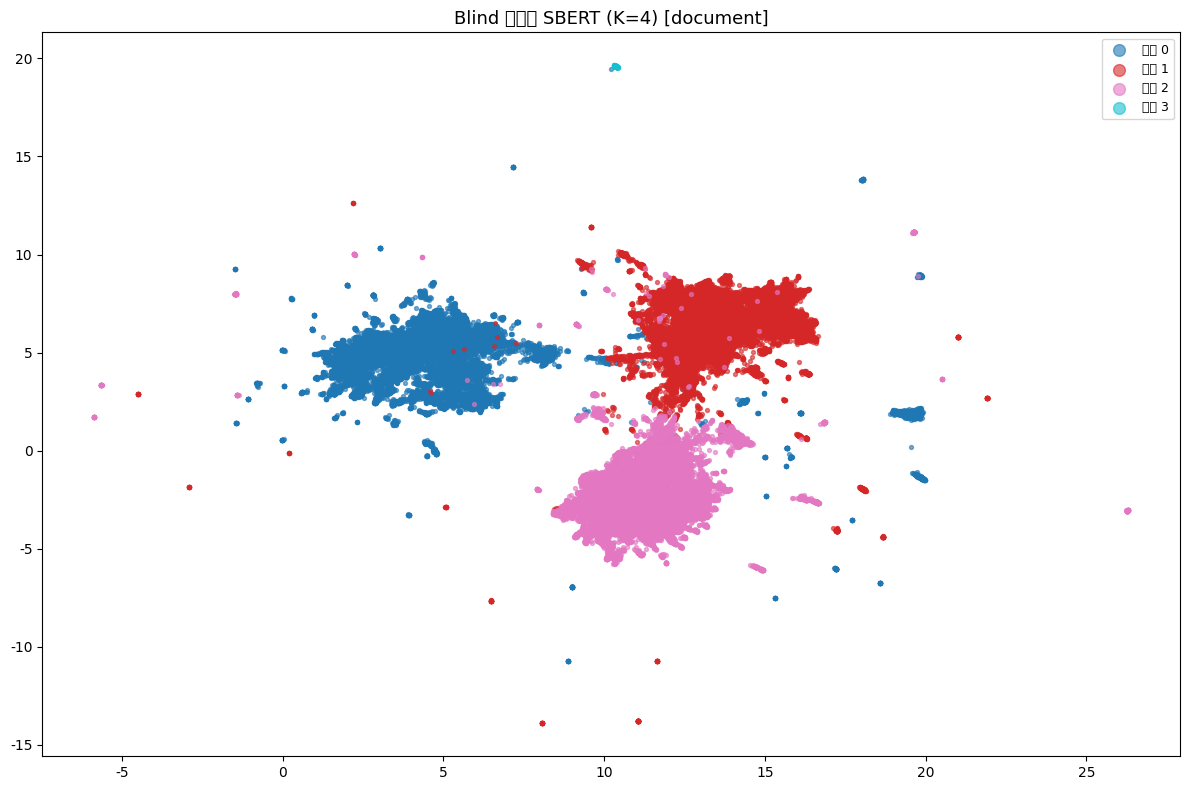

In [15]:
N_SBERT = 4   # 직접 수정 가능: N_SBERT = 7

km_sbert = KMeans(n_clusters=N_SBERT, random_state=42, n_init=10)
analysis_df["cluster_sbert"] = km_sbert.fit_predict(reduced_10d)
print(f"군집별 {'문장' if ANALYSIS_MODE == 'sentence' else '게시글'} 수 (SBERT):")
print(analysis_df["cluster_sbert"].value_counts().sort_index())

reducer_2d = umap.UMAP(n_components=2, metric="cosine", random_state=42)
xy_s = reducer_2d.fit_transform(embeddings)

cmap_s = plt.cm.get_cmap("tab10", N_SBERT)
plt.figure(figsize=(12, 8))
for c in range(N_SBERT):
    mask = analysis_df["cluster_sbert"] == c
    plt.scatter(xy_s[mask, 0], xy_s[mask, 1], s=8, alpha=0.6,
                color=cmap_s(c), label=f"군집 {c}")
plt.legend(markerscale=3, fontsize=9)
plt.title(f"Blind 번아웃 SBERT (K={N_SBERT}) [{ANALYSIS_MODE}]", fontsize=13)
plt.tight_layout(); plt.savefig(f"sbert_cluster_2d_{ANALYSIS_MODE}.png", dpi=150); plt.show()

### 3-4. 군집별 키워드(TF-IDF) & 대표 텍스트(코사인 유사도)

In [16]:
from sklearn.metrics.pairwise import cosine_similarity

tfidf_raw = TfidfVectorizer(max_features=5000)
tfidf_raw.fit(analysis_df[TEXT_COL])
feature_names_raw = tfidf_raw.get_feature_names_out()

unit = "문장" if ANALYSIS_MODE == "sentence" else "게시글"
print("=" * 70)
for c in range(N_SBERT):
    idx = analysis_df[analysis_df["cluster_sbert"] == c].index.tolist()
    cluster_embs = embeddings[idx]
    centroid = cluster_embs.mean(axis=0, keepdims=True)
    sims = cosine_similarity(centroid, cluster_embs)[0]
    top5 = [idx[i] for i in sims.argsort()[::-1][:5]]

    mat = tfidf_raw.transform(analysis_df.loc[idx, TEXT_COL].tolist())
    keywords = [feature_names_raw[i]
                for i in mat.mean(axis=0).A1.argsort()[::-1][:20]]

    print(f"\n【SBERT 군집 {c}】 ({len(idx)}{unit})")
    print(f"  키워드: {' | '.join(keywords)}")
    print(f"  대표 {unit}:")
    for rank, g in enumerate(top5, 1):
        preview = analysis_df.loc[g, TEXT_COL]
        print(f"    {rank}. {preview[:80]}{'...' if len(preview) > 80 else ''}")
print("=" * 70)


【SBERT 군집 0】 (19445게시글)
  키워드: 원룸 | 월세 | 전세 | 투룸 | 풀옵션 | 신축 | 매매 | 가능 | 아파트 | 매물 | 첫입주 | 관리비 | 정보 | 신축빌라 | 도보 | 빌라 | 주택 | 옵션 | 오피스텔 | 입주
  대표 게시글:
    1. 중개.부동산말머리아파트사천kcc23평 고층 월세시에.중문옵션즉시입주가능월세150070봄날01098784802 봄날부동산 정소장입니다. 사천kcc...
    2. 투룸금천구로강서양천양천향교역 도보 3분 풀옵션 전세대출 가능 신축 첫입주 피터팬 APP, WEB 동시 노출 동의 여부 Y N 주소 양천향교역 도...
    3. 원룸마포구용산구홍대역3분 동교동삼거리 실개천흐르는 연트럴파크 트리플역세권 신축원룸풀최고옵션 7월10일이후입주시작!!!!!보200부터 전세억잇 어...
    4. 원룸관악구동작구신림역 7번출구 도보3분 신축첫입주 채광 좋고 넓은7평에서8평사이 풀옵션 원룸 100060 중개수수료 지불한방 계약서는 부동산에서...
    5. 원룸마포구용산구말머리월세이촌역 도보3분거리 초역세권 500020 풀옵션 약8평 원룸 1. 매물종류 풀옵션 원룸 2. 매물크기 순 실평수 5평 내...

【SBERT 군집 1】 (18118게시글)
  키워드: 옵션 | 아파트 | 인테리어 | 에어컨 | 옵션으로 | 시스템에어컨 | 너무 | 입주 | 마이너스 | 자유 | 시스템 | 하는게 | 입주청소 | 신축 | 입주시 | 혹시 | 선택 | 많이 | 어떻게 | 하고
  대표 게시글:
    1. 인테리어 질문신축 입주아파트 옵션선택질문 2년후 입주하는 아파트 옵션 선택을 이번주에 하러가는데 인테리어 선배님들의 고견 여쭙니다. 조합원 물건...
    2. 인테리어 질문신축 입주아파트 옵션선택질문 2년후 입주하는 아파트 옵션 선택을 이번주에 하러가는데 인테리어 선배님들의 고견 여쭙니다. 조합원 물건...
    3. 인테리어 질문신축 입주아파트 옵션선택질문 2년후 입주하는 아파트 옵션 선택을 이번주에 하러

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# 1. 군집별 중심점(Centroid) 계산 및 대표 문장 추출
for c in range(N_SBERT):
    # 해당 군집에 속한 데이터의 인덱스 및 임베딩 추출
    idx = analysis_df[analysis_df["cluster_sbert"] == c].index
    cluster_embs = embeddings[idx]
    
    # 군집의 산술 평균(중심점) 계산 및 코사인 유사도 측정
    centroid = cluster_embs.mean(axis=0, keepdims=True)
    sims = cosine_similarity(centroid, cluster_embs)[0]
    
    # 중심점에 가장 가까운 'TOP 5 대표 문장' 확정
    top5_idx = [idx[i] for i in sims.argsort()[::-1][:5]]

# 2. TF-IDF 기반 군집별 핵심 키워드 도출
    # 군집 내 문서 집합에 대해 TF-IDF 행렬 생성
    mat = tfidf_raw.transform(analysis_df.loc[idx, "text"])
    
    # 단어별 평균 중요도 순으로 '상위 20개 핵심어' 추출
    keywords = [feature_names_raw[i] for i in mat.mean(axis=0).A1.argsort()[::-1][:20]]

---
## 세 방법 나란히 비교 (UMAP 2D)

## 결과 저장

In [17]:
output_csv   = f"{RAW_CSV}_{ANALYSIS_MODE}.csv"
output_model = f"{RAW_CSV}_{ANALYSIS_MODE}.model"

analysis_df.to_csv(output_csv, index=False, encoding="utf-8-sig")
#d2v.save(output_model)

print("저장 완료 ✅")
print(f"  → {output_csv}")
print(f"  → {output_model}")
print(f"  → tfidf/d2v/sbert_cluster_2d_{ANALYSIS_MODE}.png")
print(f"  → {RAW_CSV}_{ANALYSIS_MODE}.png")
analysis_df.head()

저장 완료 ✅
  → /content/drive/MyDrive/Colab Notebooks/LG전자DX스쿨/CX Project/data/03_Apartment_Options_merged.csv_document.csv
  → /content/drive/MyDrive/Colab Notebooks/LG전자DX스쿨/CX Project/data/03_Apartment_Options_merged.csv_document.model
  → tfidf/d2v/sbert_cluster_2d_document.png
  → /content/drive/MyDrive/Colab Notebooks/LG전자DX스쿨/CX Project/data/03_Apartment_Options_merged.csv_document.png


,doc_idx,text,tokens,tokens_str,cluster_sbert
0,0,"자유수다방신축아파트 옵션은,,?도와주세여.. 곧 신축 아파트 옵션을 골라야하는데.....","[자유, 다방, 신축, 아파트, 옵션, 신축, 아파트, 옵션, 고르, 시스템, 에어...",자유 다방 신축 아파트 옵션 신축 아파트 옵션 고르 시스템 에어컨 바닥 생각 고민 ...,1
1,1,자유게시판아파트 옵션 확인할 수 있는 곳 있나요? 주변에 지어진지 56년 정도 된 ...,"[자유, 게시판, 아파트, 옵션, 확인, 주변, 정도, 아파트, 단지, 고객, 설명...",자유 게시판 아파트 옵션 확인 주변 정도 아파트 단지 고객 설명 자료 만들 아파트 ...,1
2,2,자유게시판아파트 에어컨 옵션관련 안녕하세요 미혼이구 결혼은 아직 예정없습니다 아파트...,"[자유, 게시판, 아파트, 에어컨, 옵션, 관련, 안녕, 미혼, 결혼, 예정, 아파...",자유 게시판 아파트 에어컨 옵션 관련 안녕 미혼 결혼 예정 아파트 거주 목적 입주 ...,1
3,3,자유게시판아파트 옵션 중도대출 받을때 옵션을 선택한다고 하는데 입주시에 입주자들과 ...,"[자유, 게시판, 아파트, 옵션, 중도, 대출, 옵션, 선택, 입주, 입주자, 에어...",자유 게시판 아파트 옵션 중도 대출 옵션 선택 입주 입주자 에어 오븐 옵션,1
4,4,고민상담신축아파트 조명 옵션 안녕하세요 청약 당첨돼서 내일 옵션계약하러갑니다 근데 ...,"[고민, 상담, 신축, 아파트, 조명, 옵션, 안녕, 청약, 당첨, 내일, 옵션계약...",고민 상담 신축 아파트 조명 옵션 안녕 청약 당첨 내일 옵션계약 조명 옵션 모르 사...,1
